# Figure 5B — do two knockouts from one module add up?

For each guide module, compares the effect actually measured in cells carrying
two knockouts from that module against the sum of the effects measured in cells
carrying each knockout on its own. A slope of one would mean the two
perturbations combine additively.

## Setup

In [1]:
library(ggplot2)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and silently breaks every "+"
# chain, producing a blank PDF. %ni% and computeR2 are inlined from Utilities.R.

`%ni%` <- Negate(`%in%`)

computeR2 <- function(response, prediction) {
    rss <- sum((response - prediction)^2, na.rm = TRUE)       # residual sum of squares
    tss <- sum((response - mean(response, na.rm = TRUE))^2)   # total sum of squares
    1 - rss / tss
}

RDS_DIR <- "/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles"

# The effect tables are keyed by the old module names, so they are read with
# those and relabelled only for display. Panel order is the published one,
# which is K_0 to K_4 from left to right.
MODULE_OF_K <- c(K_0 = "M2", K_1 = "M3", K_2 = "M6", K_3 = "M5", K_4 = "M1", K_5 = "M4")
PANEL_ORDER <- c("M2", "M3", "M6", "M5", "M1")
MODULE_KS   <- names(MODULE_OF_K)[match(PANEL_ORDER, MODULE_OF_K)]

## The two sets of effect sizes

Both files are regression results in long form: one row per response gene per
term. They are reduced to the module terms, then pivoted to a gene-by-module
matrix of coefficients.

`doubles` holds the effects measured in cells carrying two knockouts from the
same module; `combos` holds the single-knockout effects the prediction is
built from.

In [2]:
readComboEffects <- function(path) {
    d <- readRDS(path)
    d <- d[d$term %ni% c("(Intercept)", "n_genes", "mt_frac", paste0("leiden", 1:9)), ]
    d[, c("std.error", "statistic", "p.value")] <- NULL

    d <- reshape(d, idvar = "respGene", timevar = "term", direction = "wide")
    rownames(d) <- d$respGene
    d$respGene  <- NULL
    colnames(d) <- sapply(colnames(d), function(x) strsplit(x, "estimate.")[[1]][2])
    d
}

doubles <- readComboEffects(file.path(RDS_DIR, "ComboEffects_doublesSameGroup.rds"))
combos  <- readComboEffects(file.path(RDS_DIR, "ComboEffects_lm_residuals.rds"))

dim(doubles)

[1] 1041    6

## Observed against predicted, per module

The prediction is twice the single-knockout effect, both knockouts being drawn
from the same module. The slope is the first principal component of the two
columns rather than a regression line, so that neither axis is privileged.

:::{note}
M4 is left out. The original notebook drops `K_5` in its own cell without
giving a reason, and that is kept here so the panel matches the published one.
:::

In [3]:
allPred <- do.call(rbind, lapply(MODULE_KS, function(k) {
    predicted <- 2 * combos[, k]     # two knockouts, each contributing its single-KO effect
    observed  <- doubles[, k]

    rotation <- prcomp(data.frame(predicted, observed))$rotation

    data.frame(Predictedvalues    = predicted,
               Observedvalues     = observed,
               Comb               = factor(unname(MODULE_OF_K[k]), levels = PANEL_ORDER),
               Gene               = rownames(combos),
               R2                 = max(round(computeR2(observed, predicted), digits = 2), 0),
               PcaFirstCompSlope  = round(rotation[2, 1] / rotation[1, 1], digits = 2))
}))

# Per-module summary, for reading alongside the panels.
unique(allPred[, c("Comb", "R2", "PcaFirstCompSlope")])

,Comb,R2,PcaFirstCompSlope
,<fct>,<dbl>,<dbl>
1,M2,0.54,1.26
1042,M3,0.24,0.78
2083,M6,0.33,1.40
3124,M5,0.00,0.64
4165,M1,0.26,1.53


## Figure 5B

`color = "red"` sits inside `aes()` for the labels and the fitted line, which
maps a constant rather than setting a colour, so both come out in ggplot's
first hue. That is what the published figure shows, so it is left alone.

agg_record_188642743 
                   2

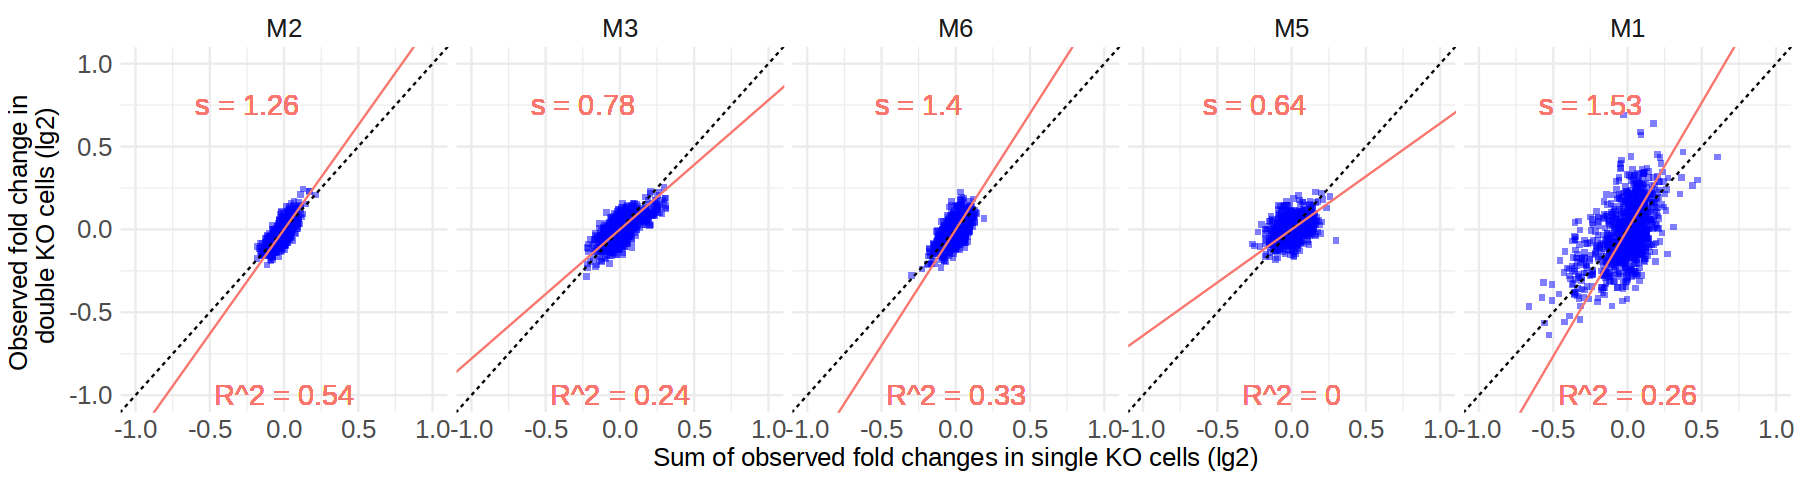

In [4]:
options(repr.plot.width = 15, repr.plot.height = 4)

p <- ggplot(allPred, aes(x = Predictedvalues, y = Observedvalues)) +
        geom_point(alpha = 0.5, shape = 15, color = "blue") +
        facet_wrap(~ Comb, ncol = length(PANEL_ORDER)) +
        geom_text(aes(label = paste0("s = ", PcaFirstCompSlope), color = "red"),
                  x = -0.25, y = 0.75, size = 6) +
        geom_text(aes(label = paste0("R^2 = ", R2), color = "red"),
                  x = 0, y = -1, size = 6) +
        geom_abline(linetype = "dashed") +
        geom_abline(aes(slope = PcaFirstCompSlope, intercept = 0, color = "red")) +
        theme_minimal() +
        theme(axis.text  = element_text(size = 15),
              axis.title = element_text(size = 15),
              strip.text = element_text(size = 15),
              legend.position = "none") +
        xlim(-1, 1) + ylim(-1, 1) +
        ylab("Observed fold change in \n double KO cells (lg2)") +
        xlab("Sum of observed fold changes in single KO cells (lg2)")

pdf("figures/Figure_5B.pdf", width = 15, height = 4)
print(p)
dev.off()

p   # show it in the notebook as well as saving it